In [3]:
import cv2
import matplotlib.pyplot as plt


In [4]:
def measureDistance(lx,ly, glx,gly,  rx,ry, grx,gry):
    # applied pythagorean theorem to calculate the distance
    dl = ((glx - lx)**2 + (gly - ly)**2) ** .5
    dr = ((grx - rx) ** 2 + (gry - ry) ** 2) ** .5

    return dl, dr

In [59]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

1
2
3
4
5


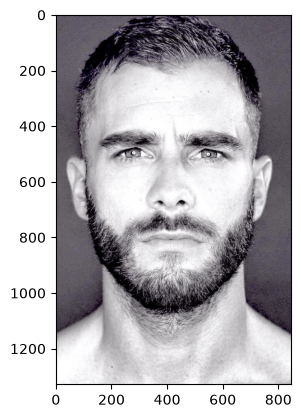

In [60]:
img = [i for i in range(1,6)]
for i in range(1,6):
    img[i-1] = cv2.imread('img/train' + str(i) + '.jpg')
    img[i-1] = cv2.cvtColor(img[i-1], cv2.COLOR_BGR2RGB)
    plt.imshow(img[i-1])
    print(i)

In [93]:
train_img = [i for i in range(0,5)]
train_rect = [i for i in range(0,5)]

for i in range(0,5):
    train_img[i] = img[i].copy()
    train_rect[i] = eye_cascade.detectMultiScale(train_img[i], scaleFactor=1.1, minNeighbors=7, 
                                                 minSize=(20,20), maxSize=(300,300))

In [94]:
for i in range(0,5):
    print(len(train_rect[i]), end=', ')

    # limit to two bounding boxes
    if len(train_rect[i]) > 2:
        train_rect[i] = train_rect[i][:2]

    print(len(train_rect[i]))

2, 2
4, 2
2, 2
4, 2
5, 2


In [83]:
left = []
right = []

for i in range(1,6):
    file = open('img/train' + str(i) + '.gnd', 'r')
    l = file.readline()
    r = file.readline()

    (glx, gly) = int(l.split(" ")[1].split(',')[0]), int(l.split(" ")[1].split(',')[1])
    (grx, gry) = int(r.split(" ")[1].split(',')[0]), int(r.split(" ")[1].split(',')[1])

    print(glx, gly)
    print(grx, gry)

    left.append((glx,gly))
    right.append((grx,gry))

69 68
103 67
1604 1504
2141 1518
151 262
254 224
926 1747
1963 1731
280 497
548 501


1.4142135623730951
542.7730214360984
7.438199353392633
131.44643812511714
153.1430320756872


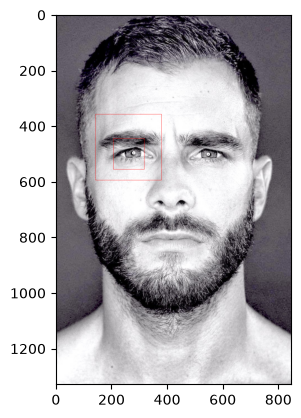

In [95]:
dr = [i for i in range(0,5)]
dl = [i for i in range(0,5)]

for i in range(0,5):
    for(x, y, w, h) in train_rect[i]:
        cv2.rectangle(train_img[i], (x,y), (x+w, y+h), (255, 0, 0), 1)

    # for each train_rect i, assign x + w//2 and y + h//2 for the left and right eye
    rx, ry = train_rect[i][0][0] + train_rect[i][0][2]//2, train_rect[i][0][1] + train_rect[i][0][3]//2
    lx, ly = train_rect[i][1][0] + train_rect[i][1][2]//2, train_rect[i][1][1] + train_rect[i][1][3]//2

    # compute the distance between the ground truth value and the detected value
    glx, gly = left[i]
    grx, gry = right[i]
    dl[i], dr[i] = measureDistance(lx,ly, glx,gly, rx,ry, grx,gry)

'''
# Define start and end points
start_point = (lx, ly)
end_point = (glx, gly)

print(start_point, end_point)

# Define color (BGR format) and thickness
color = (0, 255, 0) # Green color
thickness = 1
cv2.line(train1_img, start_point, end_point, color, thickness)

# Define start and end points
start_point_r = (rx, ry)
end_point_r = (grx, gry)

print(start_point_r, end_point_r)

# Define color (BGR format) and thickness
color = (0, 0, 255) # Green color
thickness = 1
cv2.line(train1_img, start_point_r, end_point_r, color, thickness)
'''
for i in range(0,5):
    pref_metric = (dl[i] + dr[i])/2
    print(pref_metric)
    plt.imshow(train_img[i])
